In [1]:
!pip install CoolProp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 56.7 MB/s eta 0:00:00


  Refrigerant : R134a
  T_evap      : -5.0 °C
  T_cond      : 40.0 °C
---------------------------------------------
  P_evap      : 2.433 bar
  P_cond      : 10.166 bar
  h1 (kJ/kg)  : 400.02
  h2 (kJ/kg)  : 440.78
  h3 (kJ/kg)  : 248.99
  h4 (kJ/kg)  : 248.99
---------------------------------------------
  COP cooling : 3.705
  COP heating : 4.705


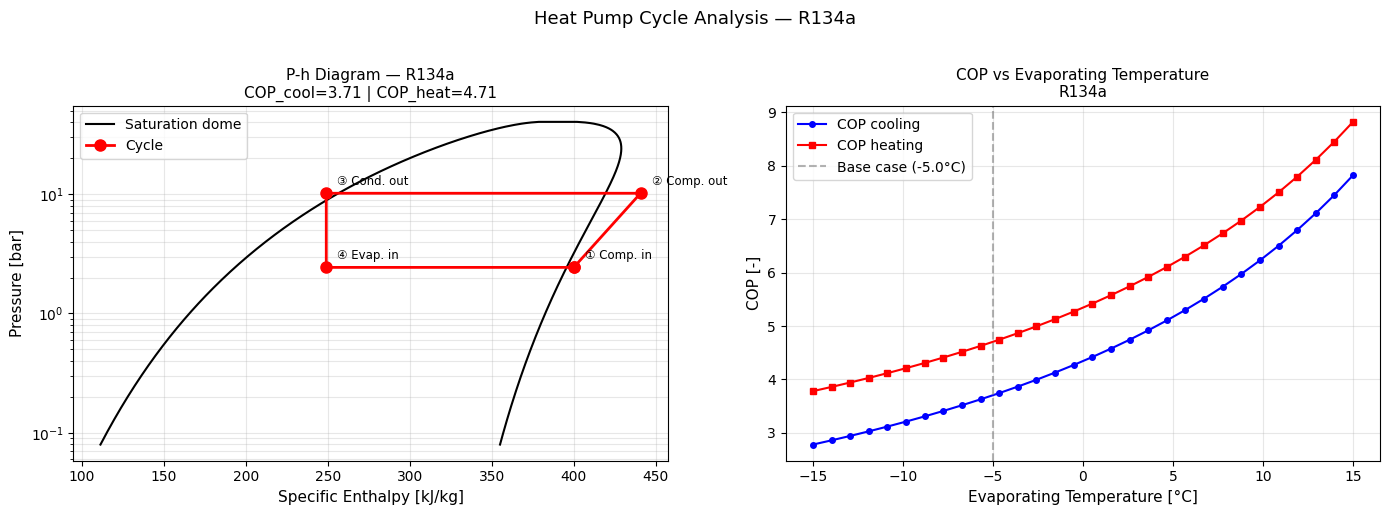

Done! Plot saved.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# ─── INPUTS (feel free to change these) ──────────────────────────────────────
refrigerant  = "R134a"   # options: "R134a", "R410A", "Propane"
T_evap_C     = -5.0      # evaporating temperature [°C]
T_cond_C     = 40.0      # condensing temperature  [°C]
superheat_K  =  5.0      # superheat at compressor inlet [K]
subcooling_K =  5.0      # subcooling at condenser outlet [K]
eta_comp     =  0.75     # isentropic efficiency [-]

# ─── °C to K ─────────────────────────────────────────────────────────────────
def C2K(T): return T + 273.15

# ─── SATURATION PRESSURES ────────────────────────────────────────────────────
P_evap = PropsSI("P", "T", C2K(T_evap_C), "Q", 1, refrigerant)
P_cond = PropsSI("P", "T", C2K(T_cond_C), "Q", 1, refrigerant)

# ─── STATE POINT 1: Compressor Inlet (superheated vapour) ────────────────────
T1 = C2K(T_evap_C) + superheat_K
h1 = PropsSI("H", "T", T1, "P", P_evap, refrigerant)
s1 = PropsSI("S", "T", T1, "P", P_evap, refrigerant)

# ─── STATE POINT 2: Compressor Outlet ────────────────────────────────────────
h2s = PropsSI("H", "P", P_cond, "S", s1, refrigerant)   # ideal
h2  = h1 + (h2s - h1) / eta_comp                         # actual

# ─── STATE POINT 3: Condenser Outlet (subcooled liquid) ──────────────────────
T3 = C2K(T_cond_C) - subcooling_K
h3 = PropsSI("H", "T", T3, "P", P_cond, refrigerant)

# ─── STATE POINT 4: After Expansion Valve ────────────────────────────────────
h4 = h3   # isenthalpic expansion

# ─── PERFORMANCE ─────────────────────────────────────────────────────────────
W_comp   = h2 - h1
Q_evap   = h1 - h4
Q_cond   = h2 - h3
COP_cool = Q_evap / W_comp
COP_heat = Q_cond / W_comp

print("=" * 45)
print(f"  Refrigerant : {refrigerant}")
print(f"  T_evap      : {T_evap_C} °C")
print(f"  T_cond      : {T_cond_C} °C")
print("-" * 45)
print(f"  P_evap      : {P_evap/1e5:.3f} bar")
print(f"  P_cond      : {P_cond/1e5:.3f} bar")
print(f"  h1 (kJ/kg)  : {h1/1e3:.2f}")
print(f"  h2 (kJ/kg)  : {h2/1e3:.2f}")
print(f"  h3 (kJ/kg)  : {h3/1e3:.2f}")
print(f"  h4 (kJ/kg)  : {h4/1e3:.2f}")
print("-" * 45)
print(f"  COP cooling : {COP_cool:.3f}")
print(f"  COP heating : {COP_heat:.3f}")
print("=" * 45)

# ─── PARAMETRIC STUDY: COP vs Evaporating Temperature ────────────────────────
T_evap_range = np.linspace(-15, 15, 30)
COP_cool_list, COP_heat_list = [], []

for T_e in T_evap_range:
    try:
        Pe   = PropsSI("P","T",C2K(T_e),"Q",1,refrigerant)
        _h1  = PropsSI("H","T",C2K(T_e)+superheat_K,"P",Pe,refrigerant)
        _s1  = PropsSI("S","T",C2K(T_e)+superheat_K,"P",Pe,refrigerant)
        _h2s = PropsSI("H","P",P_cond,"S",_s1,refrigerant)
        _h2  = _h1 + (_h2s - _h1)/eta_comp
        _h3  = PropsSI("H","T",C2K(T_cond_C)-subcooling_K,"P",P_cond,refrigerant)
        COP_cool_list.append((_h1-_h3)/(_h2-_h1))
        COP_heat_list.append((_h2-_h3)/(_h2-_h1))
    except:
        COP_cool_list.append(np.nan)
        COP_heat_list.append(np.nan)

# ─── PLOT 1: P-h Diagram ─────────────────────────────────────────────────────
T_crit = PropsSI("Tcrit", refrigerant)
T_sat_range = np.linspace(C2K(-70), T_crit * 0.999, 300)

h_liq, h_vap, P_sat = [], [], []
for T in T_sat_range:
    try:
        h_liq.append(PropsSI("H","T",T,"Q",0,refrigerant)/1e3)
        h_vap.append(PropsSI("H","T",T,"Q",1,refrigerant)/1e3)
        P_sat.append(PropsSI("P","T",T,"Q",0,refrigerant)/1e5)
    except:
        pass

h_cycle = [h1/1e3, h2/1e3, h3/1e3, h4/1e3, h1/1e3]
P_cycle = [P_evap/1e5, P_cond/1e5, P_cond/1e5, P_evap/1e5, P_evap/1e5]
labels  = ["① Comp. in", "② Comp. out", "③ Cond. out", "④ Evap. in"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# P-h plot
ax = axes[0]
ax.plot(h_liq + h_vap[::-1], P_sat + P_sat[::-1],
        "k-", linewidth=1.5, label="Saturation dome")
ax.plot(h_cycle, P_cycle, "r-o", linewidth=2, markersize=8, label="Cycle")
for i,(h,P,lbl) in enumerate(zip(h_cycle[:-1], P_cycle[:-1], labels)):
    ax.annotate(lbl, (h,P), textcoords="offset points",
                xytext=(8,6), fontsize=8.5)
ax.set_yscale("log")
ax.set_xlabel("Specific Enthalpy [kJ/kg]", fontsize=11)
ax.set_ylabel("Pressure [bar]",            fontsize=11)
ax.set_title(f"P-h Diagram — {refrigerant}\n"
             f"COP_cool={COP_cool:.2f} | COP_heat={COP_heat:.2f}", fontsize=11)
ax.legend(); ax.grid(True, which="both", alpha=0.3)

# COP vs T_evap plot
ax2 = axes[1]
ax2.plot(T_evap_range, COP_cool_list, "b-o", markersize=4, label="COP cooling")
ax2.plot(T_evap_range, COP_heat_list, "r-s", markersize=4, label="COP heating")
ax2.axvline(T_evap_C, color="gray", linestyle="--", alpha=0.6,
            label=f"Base case ({T_evap_C}°C)")
ax2.set_xlabel("Evaporating Temperature [°C]", fontsize=11)
ax2.set_ylabel("COP [-]",                      fontsize=11)
ax2.set_title(f"COP vs Evaporating Temperature\n{refrigerant}", fontsize=11)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f"Heat Pump Cycle Analysis — {refrigerant}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("heat_pump_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done! Plot saved.")

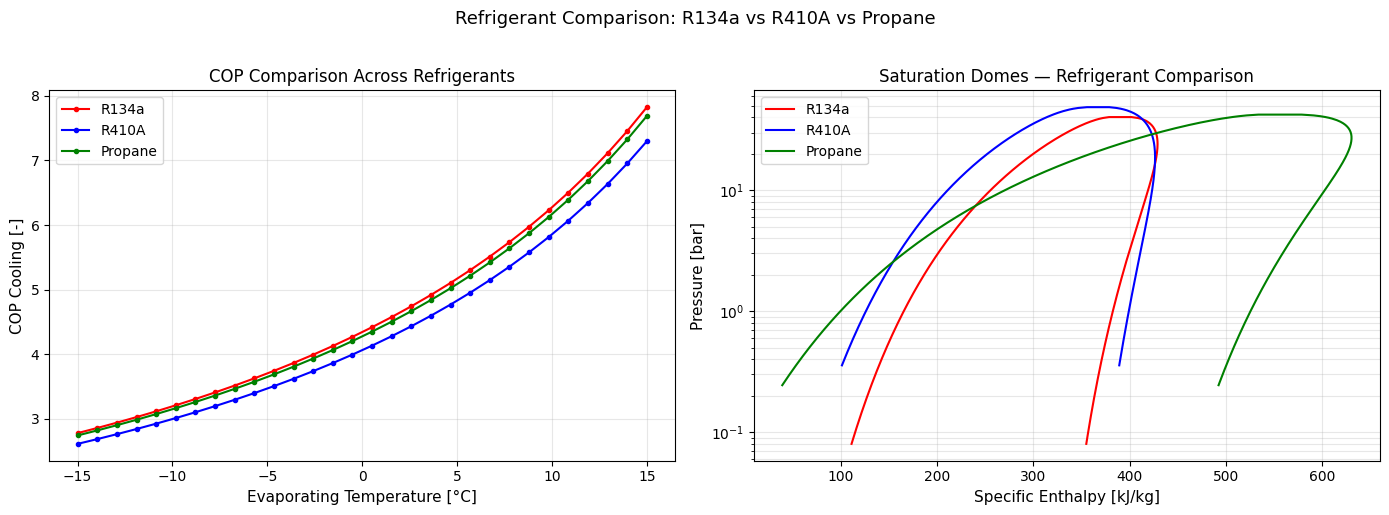

In [3]:
# ─── REFRIGERANT COMPARISON ───────────────────────────────────────────────────
refrigerants = ["R134a", "R410A", "Propane"]
colors = ["red", "blue", "green"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ref, col in zip(refrigerants, colors):
    # Base case COP
    Pe   = PropsSI("P","T",C2K(-5),"Q",1,ref)
    Pc   = PropsSI("P","T",C2K(40),"Q",1,ref)
    _h1  = PropsSI("H","T",C2K(-5)+5,"P",Pe,ref)
    _s1  = PropsSI("S","T",C2K(-5)+5,"P",Pe,ref)
    _h2s = PropsSI("H","P",Pc,"S",_s1,ref)
    _h2  = _h1 + (_h2s - _h1)/0.75
    _h3  = PropsSI("H","T",C2K(40)-5,"P",Pc,ref)

    # COP curve
    T_range = np.linspace(-15, 15, 30)
    cops = []
    for T_e in T_range:
        try:
            Pe_  = PropsSI("P","T",C2K(T_e),"Q",1,ref)
            h1_  = PropsSI("H","T",C2K(T_e)+5,"P",Pe_,ref)
            s1_  = PropsSI("S","T",C2K(T_e)+5,"P",Pe_,ref)
            h2s_ = PropsSI("H","P",Pc,"S",s1_,ref)
            h2_  = h1_ + (h2s_-h1_)/0.75
            h3_  = PropsSI("H","T",C2K(40)-5,"P",Pc,ref)
            cops.append((h1_-h3_)/(h2_-h1_))
        except:
            cops.append(np.nan)

    axes[0].plot(T_range, cops, color=col, marker="o",
                 markersize=3, label=ref)

    # P-h saturation dome
    T_crit_ = PropsSI("Tcrit", ref)
    T_s = np.linspace(C2K(-70), T_crit_*0.999, 200)
    hl, hv, ps = [], [], []
    for T in T_s:
        try:
            hl.append(PropsSI("H","T",T,"Q",0,ref)/1e3)
            hv.append(PropsSI("H","T",T,"Q",1,ref)/1e3)
            ps.append(PropsSI("P","T",T,"Q",0,ref)/1e5)
        except:
            pass
    axes[1].plot(hl + hv[::-1], ps + ps[::-1],
                 color=col, linewidth=1.5, label=ref)

axes[0].set_xlabel("Evaporating Temperature [°C]", fontsize=11)
axes[0].set_ylabel("COP Cooling [-]", fontsize=11)
axes[0].set_title("COP Comparison Across Refrigerants", fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_yscale("log")
axes[1].set_xlabel("Specific Enthalpy [kJ/kg]", fontsize=11)
axes[1].set_ylabel("Pressure [bar]", fontsize=11)
axes[1].set_title("Saturation Domes — Refrigerant Comparison", fontsize=12)
axes[1].legend(); axes[1].grid(True, which="both", alpha=0.3)

plt.suptitle("Refrigerant Comparison: R134a vs R410A vs Propane",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("refrigerant_comparison.png", dpi=150, bbox_inches="tight")
plt.show()